# Cultural Adaptation Simulation

This notebook implements a cross-cultural weighting model for agent response style selection and trust delta analysis.

Core equations:
- $C_f = \beta_1 \cdot Formality + \beta_2 \cdot Directness + \beta_3 \cdot ContextDepth$
- $Style = \arg\max_k S_k(C_f, u)$


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Simulation settings
rng = np.random.default_rng(21)
n_per_cohort = 80
cohorts = ['Spain-local', 'Asian-multilingual', 'Mixed-global']

# Weight vectors (beta) by cohort hypothesis
# [Formality, Directness, ContextDepth]
beta = {
    'Spain-local': np.array([0.25, 0.40, 0.35]),
    'Asian-multilingual': np.array([0.35, 0.20, 0.45]),
    'Mixed-global': np.array([0.30, 0.35, 0.35]),
}


In [3]:
# Candidate response styles as feature vectors
styles = {
    'Direct-Concise': np.array([0.40, 0.90, 0.30]),
    'Contextual-Relational': np.array([0.75, 0.35, 0.90]),
    'Balanced-Professional': np.array([0.60, 0.65, 0.65]),
}

def choose_style(user_pref, tau=0.35):
    """Score each style and return best style and score map."""
    scores = {}
    for name, v in styles.items():
        # Similarity score: high when style vector close to user preference vector
        scores[name] = 1.0 - np.linalg.norm(user_pref - v) / np.sqrt(3)
    best = max(scores, key=scores.get)
    # Optional gate: if best is too weak, fallback to balanced style
    if scores[best] < tau:
        return 'Balanced-Professional', scores
    return best, scores


In [4]:
rows = []

for cohort in cohorts:
    b = beta[cohort]

    # Generate latent user preference signals for each interaction
    # Values in [0,1] for Formality/Directness/ContextDepth preferences
    F = np.clip(rng.normal(0.62 if cohort != 'Spain-local' else 0.52, 0.14, n_per_cohort), 0, 1)
    D = np.clip(rng.normal(0.55 if cohort != 'Asian-multilingual' else 0.44, 0.15, n_per_cohort), 0, 1)
    C = np.clip(rng.normal(0.66 if cohort != 'Spain-local' else 0.58, 0.13, n_per_cohort), 0, 1)

    # Compute cultural-fit scalar C_f for each interaction
    Cf = b[0]*F + b[1]*D + b[2]*C

    for i in range(n_per_cohort):
        user_pref = np.array([F[i], D[i], C[i]])
        style_selected, score_map = choose_style(user_pref)

        # Baseline trust from underlying interaction quality signal
        trust_baseline = np.clip(0.45 + 0.50*Cf[i] + rng.normal(0, 0.04), 0, 1)

        # Adapted trust adds style-match benefit relative to neutral style score
        neutral_score = score_map['Balanced-Professional']
        chosen_score = score_map[style_selected]
        trust_adapted = np.clip(trust_baseline + 0.18*(chosen_score - neutral_score), 0, 1)

        rows.append({
            'cohort': cohort,
            'F': F[i],
            'D': D[i],
            'ContextDepth': C[i],
            'C_f': Cf[i],
            'style': style_selected,
            'trust_baseline': trust_baseline,
            'trust_adapted': trust_adapted,
            'trust_delta': trust_adapted - trust_baseline,
        })

df = pd.DataFrame(rows)
df.head()


,cohort,F,D,ContextDepth,C_f,style,trust_baseline,trust_adapted,trust_delta
0,Spain-local,0.570228,0.580086,0.647317,0.601153,Balanced-Professional,0.695607,0.695607,0.000000
1,Spain-local,0.731495,0.423175,0.468784,0.516218,Balanced-Professional,0.654142,0.654142,0.000000
2,Spain-local,0.269914,0.740865,0.565826,0.561863,Direct-Concise,0.739278,0.740997,0.001719
3,Spain-local,0.756126,0.688937,0.487839,0.635350,Balanced-Professional,0.751005,0.751005,0.000000
4,Spain-local,0.513376,0.654089,0.690633,0.631701,Balanced-Professional,0.775708,0.775708,0.000000


In [5]:
summary = df.groupby('cohort').agg(
    mean_Cf=('C_f', 'mean'),
    mean_trust_baseline=('trust_baseline', 'mean'),
    mean_trust_adapted=('trust_adapted', 'mean'),
    mean_trust_delta=('trust_delta', 'mean')
).reset_index()
summary


,cohort,mean_Cf,mean_trust_baseline,mean_trust_adapted,mean_trust_delta
0,Asian-multilingual,0.620276,0.762439,0.768308,0.005869
1,Mixed-global,0.625413,0.767848,0.769420,0.001572
2,Spain-local,0.538521,0.717537,0.717916,0.000379


In [6]:
style_mix = (df.groupby(['cohort', 'style']).size()
             .rename('count')
             .reset_index())
style_mix['share'] = style_mix.groupby('cohort')['count'].transform(lambda s: s / s.sum())
style_mix


,cohort,style,count,share
0,Asian-multilingual,Balanced-Professional,48,0.600
1,Asian-multilingual,Contextual-Relational,32,0.400
2,Mixed-global,Balanced-Professional,68,0.850
3,Mixed-global,Contextual-Relational,12,0.150
4,Spain-local,Balanced-Professional,70,0.875
5,Spain-local,Contextual-Relational,6,0.075
6,Spain-local,Direct-Concise,4,0.050


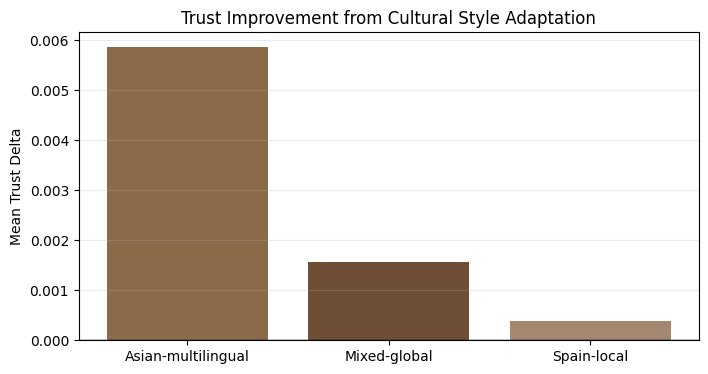

In [7]:
# Plot 1: trust delta by cohort
plt.figure(figsize=(8,4))
plt.bar(summary['cohort'], summary['mean_trust_delta'], color=['#8b6a4a', '#6e4f36', '#a3876e'])
plt.axhline(0, color='black', linewidth=1)
plt.ylabel('Mean Trust Delta')
plt.title('Trust Improvement from Cultural Style Adaptation')
plt.grid(axis='y', alpha=0.25)
plt.show()


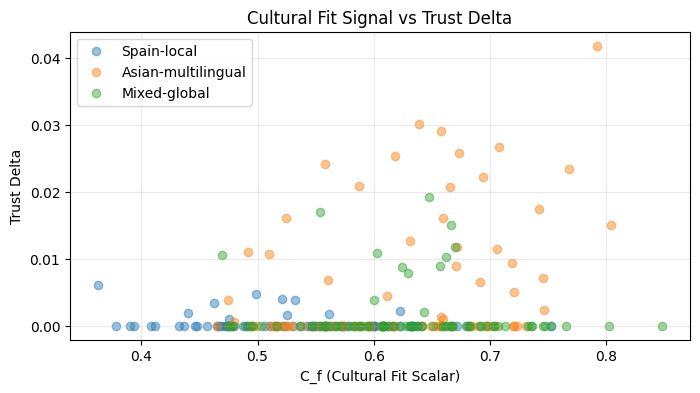

In [8]:
# Plot 2: C_f vs trust delta scatter
plt.figure(figsize=(8,4))
for cohort in cohorts:
    d = df[df['cohort'] == cohort]
    plt.scatter(d['C_f'], d['trust_delta'], alpha=0.45, label=cohort)
plt.xlabel('C_f (Cultural Fit Scalar)')
plt.ylabel('Trust Delta')
plt.title('Cultural Fit Signal vs Trust Delta')
plt.legend()
plt.grid(alpha=0.25)
plt.show()


In [9]:
# Export simulation outputs for reproducibility
out_path = '../../../data/simulations/cultural-adaptation-sim.csv'
df.to_csv(out_path, index=False)
print(f'Wrote: {out_path}')


Wrote: ../../../data/simulations/cultural-adaptation-sim.csv


## Interpretation Notes

- Compare `mean_trust_delta` across cohorts to evaluate adaptation benefit.
- Track style distribution share to inspect over-fitting to one style.
- Replace synthetic parameters with Madrid pilot observations as available.
